In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.mixture import GaussianMixture
import joblib
import matplotlib.pyplot as plt
from dotenv import load_dotenv
import os

project_root = '/Users/namansoni/Project/macro-regime-classifier'

df = pd.read_csv(os.path.join(project_root, 'data', 'macro_features_clean.csv'), index_col = 0, parse_dates = True)

print(df.head())
print(df.shape)

                 cpi  unemployment  gdp_growth  yield_curve  credit_spread  \
2001-01-31  0.037212           0.3        -1.3         0.57           2.62   
2001-02-28  0.035294           0.0        -1.3         0.51           2.88   
2001-03-31  0.029825           0.1        -1.3         0.75           3.04   
2001-04-30  0.032183           0.1         2.5         1.05           2.73   
2001-05-31  0.035631          -0.1         2.5         1.21           2.65   

            consumer_sent  indust_prod  
2001-01-31           -3.7      -0.4395  
2001-02-28           -4.1      -0.5986  
2001-03-31            0.9      -0.1872  
2001-04-30           -3.1      -0.3271  
2001-05-31            3.6      -0.4336  
(307, 7)


In [2]:
scaler = StandardScaler()

arrays = scaler.fit_transform(df)

In [3]:
scaled_df = pd.DataFrame(arrays, index = df.index, columns = df.columns)
print(scaled_df)

                 cpi  unemployment  gdp_growth  yield_curve  credit_spread  \
2001-01-31  0.662064      0.461170   -0.710597    -0.555839       0.218070   
2001-02-28  0.551779     -0.001507   -0.710597    -0.619306       0.562818   
2001-03-31  0.237267      0.152719   -0.710597    -0.365437       0.774971   
2001-04-30  0.372857      0.152719    0.051826    -0.048100       0.363925   
2001-05-31  0.571141     -0.155733    0.051826     0.121146       0.257849   
...              ...           ...         ...          ...            ...   
2026-03-31  0.411787     -0.155733   -0.028429    -0.619306      -0.882473   
2026-04-30  0.695439     -0.001507   -0.028429    -0.608728      -1.001809   
2026-05-31  0.918185     -0.001507   -0.028429    -0.661617      -1.174183   
2026-06-30  0.513896     -0.155733   -0.028429    -0.841441      -1.227221   
2026-07-31  0.513896     -0.155733   -0.028429    -0.767396      -1.121145   

            consumer_sent  indust_prod  
2001-01-31      -0.807

In [4]:
print(scaled_df.mean())
print(scaled_df.std())
#Since each column in std is off by the same amount, its clear that pandas is using the sample calculation for std, while sklearn uses the population calculation causing a small but recurring difference. 

cpi              5.786179e-17
unemployment    -1.446545e-17
gdp_growth       1.157236e-17
yield_curve     -9.257886e-17
credit_spread   -3.008813e-16
consumer_sent    2.314471e-17
indust_prod     -8.679268e-18
dtype: float64
cpi              1.001633
unemployment     1.001633
gdp_growth       1.001633
yield_curve      1.001633
credit_spread    1.001633
consumer_sent    1.001633
indust_prod      1.001633
dtype: float64


In [5]:
src_folder = os.path.join(project_root, 'src')

os.makedirs(src_folder, exist_ok = True)

joblib.dump(scaler, os.path.join(project_root, src_folder, 'scaler.pkl'))

['/Users/namansoni/Project/macro-regime-classifier/src/scaler.pkl']

In [6]:
loaded_scaler = joblib.load(os.path.join(src_folder, 'scaler.pkl'))
print(loaded_scaler.mean_)

[ 2.56983418e-02  9.77198697e-04  2.24169381e+00  1.09547231e+00
  2.45553746e+00 -2.07166124e-01  3.38009772e-02]


In [7]:
# Day 2 -> Computing BIC scores for each of the K values from 1-7 for each sector, and determining which K value is optimal. 

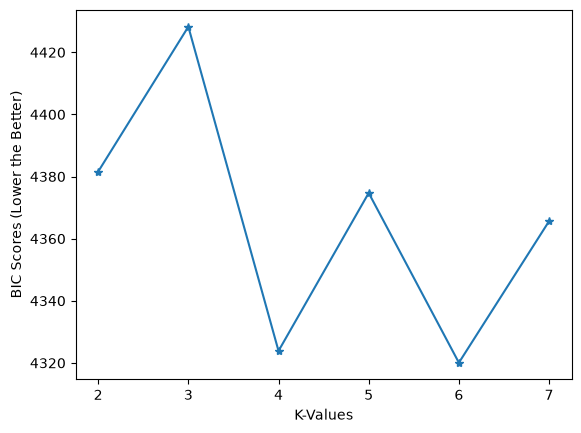

[4381.5731498015875, 4428.242766677294, 4323.862807479297, 4374.713952129514, 4320.067991881112, 4365.628750683434]


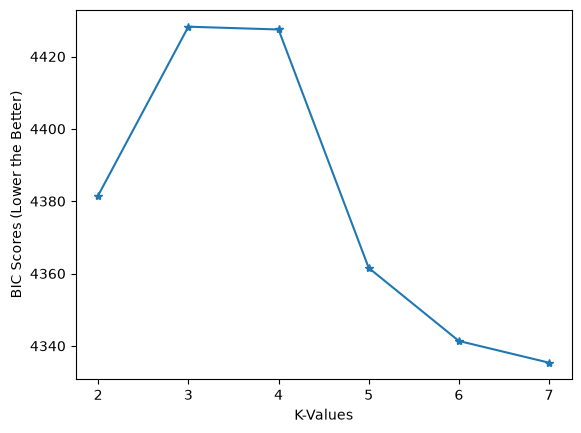

[4381.5731498015875, 4428.242766677294, 4427.472635947292, 4361.5574318746385, 4341.355525762141, 4335.3514377380425]


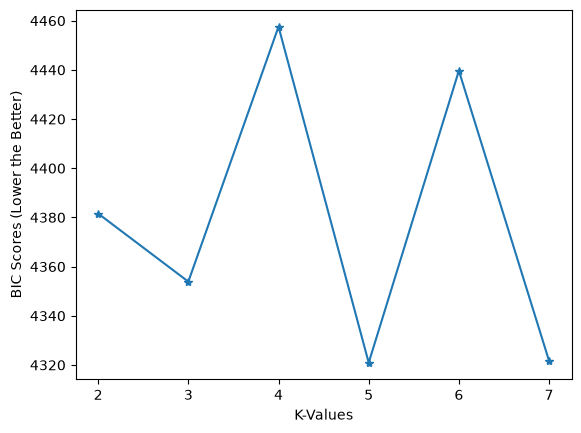

[4381.5731498015875, 4353.883935716055, 4457.559761774961, 4320.924810829713, 4439.646545980286, 4321.668250805133]


In [8]:
bic_scores = []
random_vals = [0, 1, 42]

for j in random_vals:
    bic_scores = []
    for i in range(2, 8):
        mixture = GaussianMixture(i, n_init = 10, random_state = j)
        mixture.fit(scaled_df)
        bic_scores.append(mixture.bic(scaled_df))
    
    k_values = list(range(2,8))
    plt.plot(k_values, bic_scores, marker = '*')
    plt.xlabel('K-Values')
    plt.ylabel('BIC Scores (Lower the Better)')
    plt.savefig(os.path.join(project_root, 'outputs', 'bic_curve.png'), dpi = 150, bbox_inches = 'tight')
    plt.show()
    print(bic_scores)

I fit the scaled data with the gaussian mixture model over the range of k values from 2-7 with 3 different random states, and stored their BIC into individual lists. The n_init was set to 50, meaning the algorithm was each time run 50 times with different randomized starting points, ensuring that the CPI values are credible. After the rederivation of data, where I removed the preceding NaN values of 2000 and only kept forward-fills, the BCI minimum along with maximums varied heavily (with over 70 points of fluctuations) across the three lists. The only one that stays stable is K = 2. Further checks also reveal that higher k values are adding clusters that are untradable, with less that 10 months. However, gmm_k3 is still saved as a comparison option in week 4, to see if the k value has an impact on the model and whether the clustering truly matters. Therefore, K=2 is the primary model. 

In [21]:
# Day 3 -> Creating two models on the scaled data. 

gmm_k3 = GaussianMixture(3, n_init = 50, random_state = 42)
gmm_k3.fit(scaled_df)
gmm_k2 = GaussianMixture(2, n_init = 50, random_state = 42)
gmm_k2.fit(scaled_df)

gmm_k7 = GaussianMixture(7, n_init = 50, random_state = 42)
gmm_k7.fit(scaled_df)

k3_pred = gmm_k3.predict(scaled_df)
k3_probs = gmm_k3.predict_proba(scaled_df)

print(k3_pred.shape)
print(k3_probs.shape)
print(np.unique(k3_pred, return_counts= True))

(307,)
(307, 3)
(array([0, 1, 2]), array([287,  17,   3]))


In [ ]:
# Testing higher k values to check if for sure k=2 is the only stable value
k7_pred = gmm_k7.predict(scaled_df)
k7_probs = gmm_k7.predict_proba(scaled_df)

print(k7_pred.shape)
print(k7_probs.shape)
print(np.unique(k7_pred, return_counts= True))

(307,)
(307, 7)
(array([0, 1, 2, 3, 4, 5, 6]), array([ 29,  10, 112,   1,   2, 150,   3]))


In [10]:
joblib.dump(gmm_k2, os.path.join(project_root, src_folder, 'gmm_k2.pkl'))
joblib.dump(gmm_k3, os.path.join(project_root, src_folder, 'gmm_k3.pkl'))

['/Users/namansoni/Project/macro-regime-classifier/src/gmm_k3.pkl']

In [11]:
print(k3_pred[:15])

[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]


In [12]:
# Day 4 ->

scaled_df.index[k3_pred == 2]

DatetimeIndex(['2020-07-31', '2020-08-31', '2020-09-30'], dtype='datetime64[us]', freq=None)

In [13]:
k3_pred[scaled_df.index.year == 2008]

array([0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1])

In [14]:
k3_pred[scaled_df.index.year == 2020]

array([0, 1, 1, 1, 1, 1, 2, 2, 2, 1, 0, 0])

In [15]:
k3_pred[scaled_df.index.year == 2019]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0])

In [16]:
df.loc['2019']

,cpi,unemployment,gdp_growth,yield_curve,credit_spread,consumer_sent,indust_prod
2019-01-31,0.014876,0.1,2.5,0.18,2.38,-7.1,-0.6915
2019-02-28,0.015189,-0.2,2.5,0.21,2.22,2.6,-0.5650
2019-03-31,0.018832,0.0,2.5,0.14,2.26,4.6,0.0386
2019-04-30,0.020006,-0.1,3.4,0.24,2.14,-1.2,-0.6017
2019-05-31,0.017959,-0.1,3.4,0.19,2.37,2.8,0.1180
2019-06-30,0.016712,0.0,3.4,0.25,2.31,-1.8,0.0455
2019-07-31,0.018263,0.1,4.8,0.13,2.13,0.2,-0.4967
2019-08-31,0.017376,-0.1,4.8,0.00,2.26,-8.6,0.6982
2019-09-30,0.016845,-0.1,4.8,0.05,2.20,3.4,-0.3473
2019-10-31,0.017340,0.1,2.8,0.17,2.18,2.3,-0.8636


In [17]:
print(df.loc['2017-01-31'])

cpi              0.025104
unemployment     0.000000
gdp_growth       2.000000
yield_curve      1.260000
credit_spread    2.230000
consumer_sent    0.300000
indust_prod     -0.260300
Name: 2017-01-31 00:00:00, dtype: float64
